# Falcon 9 / BCHH Figure Generation Notebook

Refactored workflow for the BCHH seismo-acoustic figure set.

This notebook is organized so that timing assumptions are explicit and easy to change:

1. Define paths, video-derived source times, sensor distances, and environmental parameters.
2. Estimate still-air, wind-corrected, and shock-speed-corrected acoustic speeds.
3. Read/cache BCHH waveform data.
4. Remove instrument responses.
5. Prepare display streams using **ZEROPHASE** filters, so plotted energy is not moved before the physical onset.
6. Make the 30-minute overview figure.
7. Optionally load synchronized SpaceX/YouTube audio.
8. Make the 20-second zoom figure either in observed UTC time or reduced source time.

Important assumption: the BCHH seismic channels are interpreted here as **ground-coupled airwaves**, not direct seismic waves. Therefore, for timing reduction and predicted arrival annotations, `HH*` channels use the acoustic propagation speed unless `HH_USE_DIRECT_SEISMIC_SPEED=True`.

## 1. Imports


In [1]:
from pathlib import Path
import warnings
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from obspy import read, Stream, Trace, UTCDateTime

# Optional: used for response inventories. If unavailable, response removal will fail
# with a clear message rather than silently producing uncorrected traces.
try:
    from flovopy.stationmetadata.build import NRL2inventory
except Exception as e:
    NRL2inventory = None
    warnings.warn(f"Could not import NRL2inventory from flovopy: {e}")

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 120,
})


## 2. User-editable configuration

Edit this cell when source-time picks, paths, sensor distances, or environmental assumptions change.

For video picks, use fractional frames explicitly. For example, if the explosion is visible on frame 2 but you infer onset between frames 1 and 2, use `frame=1.5`.


In [2]:
# -----------------------------------------------------------------------------
# Paths
# -----------------------------------------------------------------------------
MINISEED_DIR = Path('/Volumes/haldata/KSC/beforePASSCAL/EVENTS/20160901_SpaceXplosion')
OUTDIR = Path('/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing_papers_reports')
OUTDIR.mkdir(parents=True, exist_ok=True)

RAW_CACHE = OUTDIR / 'phase1234_raw.mseed'
CORRECTED_CACHE = OUTDIR / 'phase1234_corrected.mseed'

AUDIO_FILE = Path('/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/02_KSC/spaceX_explosion_movie/syncedsound2.mp3')

# -----------------------------------------------------------------------------
# Video-derived source times
# -----------------------------------------------------------------------------
FPS = 30.0
EVENT_DATE = '2016-09-01'

def utc_from_hms_frame(hh, mm, ss, frame=0.0, fps=FPS, date=EVENT_DATE):
    """Convert HH:MM:SS + video frame number to UTCDateTime."""
    return UTCDateTime(f"{date}T{hh:02d}:{mm:02d}:{ss:02d}") + frame / fps

# Initial second-stage rupture: visible near frame 2; inferred onset between frames 1 and 2.
EXPLOSION_TIME = utc_from_hms_frame(13, 7, 12, frame=1.5)

# Update these frame picks as needed.
FIRST_STAGE = utc_from_hms_frame(13, 7, 15, frame=22)
CAPSULE = utc_from_hms_frame(13, 7, 24, frame=16)

SOURCE_EVENTS = {
    "Second\nstage": EXPLOSION_TIME,
    "First\nstage": FIRST_STAGE,
    "Capsule": CAPSULE,
}

# Use this to show uncertainty windows around video picks.
VIDEO_PICK_UNCERTAINTY_S = 1.0 / FPS

# -----------------------------------------------------------------------------
# BCHH sensor distances from SLC-40.
# -----------------------------------------------------------------------------
SENSOR_DISTANCES_M = {
    "HHE": 1421.8,
    "HHN": 1421.8,
    "HHZ": 1421.8,
    "HD1": 1442.2,
    "HD2": 1410.2,
    "HD3": 1414.8,
}

CHANNEL_ORDER = ["HD1", "HD2", "HD3", "HHE", "HHN", "HHZ"]

# Since the observed seismic energy is interpreted as ground-coupled airwave,
# HH channels use the acoustic speed by default for reduction/annotations.
HH_USE_DIRECT_SEISMIC_SPEED = False
DIRECT_SEISMIC_SPEED_MPS = 1100.0

# -----------------------------------------------------------------------------
# Environmental/acoustic assumptions
# -----------------------------------------------------------------------------
RelativeHumidityPercent = 92
TemperatureF = 80
WindDirectionFromDeg = 150
WindDirectionDeg = (WindDirectionFromDeg + 180) % 360  # direction wind blows TOWARD
WindSpeedKnots = 10
WindSpeedMps = WindSpeedKnots * 0.514444
RAY_AZIMUTH_DEG = 19.0  # SLC40 -> BCHH bearing
REFERENCE_DISTANCE_M = 1400.0
REFERENCE_OVERPRESSURE_PA = 1400.0

# -----------------------------------------------------------------------------
# Figure windows and phase annotations
# -----------------------------------------------------------------------------
PRE_EVENT_SEC = 180
POST_EVENT_SEC = 1800
PLOT_START = EXPLOSION_TIME - 150
PLOT_END = EXPLOSION_TIME + POST_EVENT_SEC

PHASES = [
    ("Phase I", EXPLOSION_TIME, EXPLOSION_TIME + 70),
    ("Phase II", UTCDateTime('2016-09-01T13:14:15'), UTCDateTime('2016-09-01T13:15:45')),
    ("Phase III", UTCDateTime('2016-09-01T13:19:12'), UTCDateTime('2016-09-01T13:25:00')),
    ("Phase IV", UTCDateTime('2016-09-01T13:29:54'), UTCDateTime('2016-09-01T13:34:54')),
]

TREMOR_START = UTCDateTime("2016-09-01T13:08:48")
TREMOR_END = UTCDateTime("2016-09-01T13:12:00")

# -----------------------------------------------------------------------------
# Filtering - causal or acausal 
# -----------------------------------------------------------------------------
ZEROPHASE=True



## 3. Estimate acoustic speeds

This cell prints the still-air speed, simple shock-speed estimate, wind projection, and combined effective speed. `ACOUSTIC_SPEED_MPS` is the value used by later timing-reduction cells.


In [3]:
from physics import effective_sound_speed_along_ray, compute_speed_of_sound, mach_vs_overpressure, fahrenheit_to_celsius
print("Using physics functions from local physics.py")

speed_of_sound = float(compute_speed_of_sound(
    fahrenheit_to_celsius(TemperatureF),
    relative_humidity=RelativeHumidityPercent,
))

print(
    f"(no wind) Speed of sound at {TemperatureF} F and "
    f"{RelativeHumidityPercent}% RH: {speed_of_sound:.1f} m/s"
)

results = mach_vs_overpressure(
    reference_distance=REFERENCE_DISTANCE_M,
    reference_overpressure=REFERENCE_OVERPRESSURE_PA,
    speed_of_sound=speed_of_sound,
)

print(
    f"At array: Mach = {results['mach_at_array']:.3f}, "
    f"speed = {results['speed_at_array']:.1f} m/s"
)

print(
    f"Along raypath: Mean Mach = {results['mean_mach']:.3f}, "
    f"speed = {results['mean_speed']:.1f} m/s"
)

acoustic_result = effective_sound_speed_along_ray(
    TemperatureF,
    relative_humidity_percent=RelativeHumidityPercent,
    wind_direction_from_deg=WindDirectionFromDeg,
    wind_speed_knots=WindSpeedKnots,
    ray_azimuth_deg=RAY_AZIMUTH_DEG,
    reference_distance=REFERENCE_DISTANCE_M,
    reference_overpressure=REFERENCE_OVERPRESSURE_PA,
)

pprint(acoustic_result)

# Preferred speed for reducing/annotating ground-coupled airwaves.
# Falls back sensibly if a custom physics.py returns different key names.
ACOUSTIC_SPEED_MPS = acoustic_result.get(
    "effective_sound_speed_with_shock_and_wind_mps",
    acoustic_result.get(
        "effective_sound_speed_mps",
        acoustic_result.get("effective_sound_speed_wind_only_mps", speed_of_sound),
    ),
)

print(f"Using ACOUSTIC_SPEED_MPS = {ACOUSTIC_SPEED_MPS:.1f} m/s")


Using physics functions from local physics.py
(no wind) Speed of sound at 80 F and 92% RH: 348.6 m/s
At array: Mach = 1.006, speed = 352.3 m/s
Along raypath: Mean Mach = 1.028, speed = 360.1 m/s
358.4548362103363
****
Still-air sound speed: 348.6 m/s, Still-air shock speed: 358.5 m/s, wind along ray: 3.4 m/s, effective sound speed: 361.8 m/s
{'effective_sound_speed_mps': np.float64(361.8298925214362),
 'ray_azimuth_deg': 19.0,
 'speed_of_sound_still_air_mps': np.float64(348.61920000000003),
 'wind_along_ray_mps': np.float64(3.3750563110999243),
 'wind_direction_to_deg': 330.0,
 'wind_speed_mps': 5.14444}
Using ACOUSTIC_SPEED_MPS = 361.8 m/s


## 4. Waveform I/O

The raw stream is cached after trimming to avoid repeatedly reading the full day files.


In [4]:
def read_bchh_stream(
    miniseed_dir: Path,
    cache_file: Path,
    starttime: UTCDateTime,
    endtime: UTCDateTime,
    overwrite_cache: bool = False,
) -> Stream:
    """Read BCHH miniSEED files and cache the trimmed/merged stream."""
    if cache_file.exists() and not overwrite_cache:
        st = read(str(cache_file))
        return st.trim(starttime, endtime, pad=False)

    st = Stream()

    # Original day-file convention used in the current working directory.
    files = sorted(miniseed_dir.glob('*.20160901T000000'))

    # Fallbacks for normal miniSEED suffixes.
    if not files:
        files = sorted(miniseed_dir.glob('*.mseed')) + sorted(miniseed_dir.glob('*.msd'))

    if not files:
        raise FileNotFoundError(f'No miniSEED files found in {miniseed_dir}')

    for fn in files:
        st += read(str(fn))

    st.trim(starttime, endtime)
    st.merge(method=1, fill_value='interpolate')
    st.write(str(cache_file), format='MSEED')
    return st


st_raw = read_bchh_stream(
    MINISEED_DIR,
    RAW_CACHE,
    EXPLOSION_TIME - PRE_EVENT_SEC,
    EXPLOSION_TIME + POST_EVENT_SEC,
)
st_raw.sort(keys=['station', 'channel'])
print(st_raw)
for tr in st_raw:
    print(tr.id, tr.stats.starttime, tr.stats.endtime, tr.stats.sampling_rate, tr.stats.npts)


6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.048000Z | 250.0 Hz, 494996 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.048000Z | 250.0 Hz, 494996 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.048000Z | 250.0 Hz, 494996 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.048000Z | 250.0 Hz, 494996 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.048000Z | 250.0 Hz, 494996 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.048000Z | 250.0 Hz, 494996 samples
FL.BCHH.00.HD1 2016-09-01T13:04:12.068000Z 2016-09-01T13:37:12.048000Z 250.0 494996
FL.BCHH.00.HD2 2016-09-01T13:04:12.068000Z 2016-09-01T13:37:12.048000Z 250.0 494996
FL.BCHH.00.HD3 2016-09-01T13:04:12.068000Z 2016-09-01T13:37:12.048000Z 250.0 494996
FL.BCHH.00.HHE 2016-09-01T13:04:12.068000Z 2016-09-01T13:37:12.048000Z 250.0 494996
FL.BCHH.00.HHN 2016-09-01T13:0

## 5. Instrument response removal

This follows the same general pattern as the Artemis 2 response-correction workflow:

- `HH*` channels: Centaur + Trillium/TCP response, output as ground velocity.
- `HD*` channels: Centaur + infraBSU response, output as pressure.

If the corrected cache already exists, it is read directly.


In [5]:
def is_seismic_channel(channel: str) -> bool:
    ch = channel.upper()
    return ch[1] in ['HL']


def is_infrasound_channel(channel: str) -> bool:
    ch = channel.upper()
    return ch[1] == 'D'

def is_audio_channel(channel: str) -> bool:
    return channel.upper() in {'AUD', 'AUDIO'}


def build_centaur_inventory_for_trace(tr, sensor: str, vpp: float, units=None):
    """Build a minimal response inventory for one Centaur-recorded trace."""
    if NRL2inventory is None:
        raise ImportError('NRL2inventory is unavailable. Install/import flovopy or provide StationXML.')

    return NRL2inventory(
        nrl_path=None,
        net=tr.stats.network,
        sta=tr.stats.station,
        loc=tr.stats.location,
        chans=[tr.stats.channel],
        datalogger='Centaur',
        sensor=sensor,
        Vpp=vpp,
        fsamp=tr.stats.sampling_rate,
        lat=0.0,
        lon=0.0,
        elev=0.0,
        depth=0.0,
        sitename='',
        ondate=tr.stats.starttime,
        offdate=tr.stats.endtime,
        sensitivity=None,
        units=units,
    )


def remove_bchh_response(
    st: Stream,
    seismic_sensor: str = 'TCP',
    seismic_vpp: float = 40.0,
    infra_sensor: str = 'infrabsu',
    infra_vpp: float = 1.0,
    infra_extra_factor: float | None = None,
    water_level: float | None = None,
) -> Stream:
    """Return a response-corrected copy of the BCHH stream."""
    out = Stream()

    for tr0 in st:
        tr = tr0.copy()
        ch = tr.stats.channel.upper()

        tr.detrend('demean')
        tr.detrend('linear')
        tr.taper(max_percentage=0.01)

        if is_seismic_channel(ch):
            inv = build_centaur_inventory_for_trace(
                tr,
                sensor=seismic_sensor,
                vpp=seismic_vpp,
                units='m/s',
            )
            tr.remove_response(
                inventory=inv,
                output='VEL',
                water_level=water_level,
                pre_filt=None,
                zero_mean=False,
                taper=False,
            )
            tr.stats.units = 'm/s'

        elif is_infrasound_channel(ch):
            inv = build_centaur_inventory_for_trace(
                tr,
                sensor=infra_sensor,
                vpp=infra_vpp,
                units='Pa',
            )
            tr.remove_response(
                inventory=inv,
                output='DEF',
                water_level=water_level,
                pre_filt=None,
                zero_mean=False,
                taper=False,
            )
            if infra_extra_factor is not None:
                tr.data = tr.data * infra_extra_factor
            tr.stats.units = 'Pa'

        else:
            warnings.warn(f'Skipping response removal for unrecognized channel {tr.id}')

        out += tr

    return out


if CORRECTED_CACHE.exists():
    st_corr = read(str(CORRECTED_CACHE))
else:
    st_corr = remove_bchh_response(st_raw)
    st_corr.write(str(CORRECTED_CACHE), format='MSEED')

st_corr.sort(keys=['station', 'channel'])
print(st_corr)


6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:12.068000Z - 2016-09-01T13:37:12.064000Z | 250.0 Hz, 495000 samples


## 6. Generic plotting and preprocessing utilities

ZEROPHASE filters can still introduce phase/group delay, so pick timing should be checked against minimally processed traces as well.


In [6]:
def trace_time_array_datetime64(tr):
    """Return matplotlib date numbers for all samples in a trace."""
    t0 = tr.stats.starttime.datetime
    sr = float(tr.stats.sampling_rate)
    seconds = np.arange(tr.stats.npts, dtype=float) / sr
    return mdates.date2num(t0) + seconds / 86400.0


def robust_scale(data, percentile=99.3):
    """Robust absolute-amplitude scale for display."""
    x = np.asarray(data, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return 1.0
    s = np.percentile(np.abs(x), percentile)
    return s if np.isfinite(s) and s > 0 else 1.0


def select_channels_in_order(st: Stream, channel_order) -> Stream:
    """Return a stream containing the first matching trace for each requested channel."""
    selected = Stream()
    for ch in channel_order:
        matches = st.select(channel=ch)
        if len(matches) == 0:
            matches = Stream([tr for tr in st if tr.stats.channel.upper() == ch.upper()])
        if len(matches):
            selected += matches[0].copy()
        else:
            warnings.warn(f'No trace found for channel {ch}')
    return selected


def preprocess_display_stream(
    st: Stream,
    starttime: UTCDateTime,
    endtime: UTCDateTime,
    infra_filter=None,
    seis_filter=None,
) -> Stream:
    """Trim, detrend, taper, and filter a stream for display only."""
    out = Stream()
    for tr0 in st:
        tr = tr0.copy()
        tr.trim(starttime, endtime, pad=True, fill_value=0.0)
        tr.detrend('demean')
        tr.detrend('linear')
        tr.taper(max_percentage=0.005)

        ch = tr.stats.channel.upper()
        if is_infrasound_channel(ch) and infra_filter is not None:
            tr.filter(**infra_filter)
        elif is_seismic_channel(ch) and seis_filter is not None:
            tr.filter(**seis_filter)

        out += tr
    return out


def acoustic_or_seismic_delay_s(channel, distance_m, acoustic_speed_mps, direct_seismic_speed_mps, hh_use_direct_seismic_speed=False):
    """Return the travel-time correction for a channel.

    HD* channels are acoustic. HH* channels are acoustic by default because they
    are interpreted as ground-coupled airwaves in this dataset.
    """
    ch = channel.upper()
    if is_audio_channel(ch):
        return 0.0
    if is_infrasound_channel(ch):
        return distance_m / acoustic_speed_mps
    if is_seismic_channel(ch):
        speed = direct_seismic_speed_mps if hh_use_direct_seismic_speed else acoustic_speed_mps
        return distance_m / speed
    return 0.0


def reduce_stream_to_source_time(
    st: Stream,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    direct_seismic_speed_mps: float = DIRECT_SEISMIC_SPEED_MPS,
    hh_use_direct_seismic_speed: bool = HH_USE_DIRECT_SEISMIC_SPEED,
    audio_delay_s: float = 0.0,
) -> Stream:
    """Shift each trace earlier by its assumed source-to-receiver travel time.

    After this operation, an airwave traveling at `acoustic_speed_mps` should
    appear at its video-derived source time.
    """
    st_red = st.copy()

    for tr in st_red:
        ch = tr.stats.channel.upper()

        if is_audio_channel(ch):
            delay_s = audio_delay_s
        elif ch in sensor_distances_m:
            delay_s = acoustic_or_seismic_delay_s(
                ch,
                sensor_distances_m[ch],
                acoustic_speed_mps,
                direct_seismic_speed_mps,
                hh_use_direct_seismic_speed=hh_use_direct_seismic_speed,
            )
        else:
            delay_s = 0.0

        print(f"Reducing {tr.id} by {delay_s:.4f} s")
        tr.stats.starttime -= delay_s
        tr.stats.processing = tr.stats.get("processing", [])
        tr.stats.processing.append(f"reduced_time_shift_minus_{delay_s:.4f}_s")

    return st_red


## 7. Build the response-corrected display stream


In [7]:
# Overview filters are intentionally modest.
OVERVIEW_INFRA_FILTER = {
    'type': 'bandpass',
    'freqmin': 0.5,
    'freqmax': 25.0,
    'corners': 4,
    'zerophase': ZEROPHASE,
}
OVERVIEW_SEIS_FILTER = OVERVIEW_INFRA_FILTER.copy()

st_ordered = select_channels_in_order(st_corr, CHANNEL_ORDER)
st_overview = preprocess_display_stream(
    st_ordered,
    PLOT_START,
    PLOT_END,
    infra_filter=OVERVIEW_INFRA_FILTER,
    seis_filter=OVERVIEW_SEIS_FILTER,
)
print(st_overview)


6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:42.052000Z - 2016-09-01T13:37:12.052000Z | 250.0 Hz, 487501 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:42.052000Z - 2016-09-01T13:37:12.052000Z | 250.0 Hz, 487501 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:42.052000Z - 2016-09-01T13:37:12.052000Z | 250.0 Hz, 487501 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:42.052000Z - 2016-09-01T13:37:12.052000Z | 250.0 Hz, 487501 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:42.052000Z - 2016-09-01T13:37:12.052000Z | 250.0 Hz, 487501 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:42.052000Z - 2016-09-01T13:37:12.052000Z | 250.0 Hz, 487501 samples


## 8. 30-minute overview figure


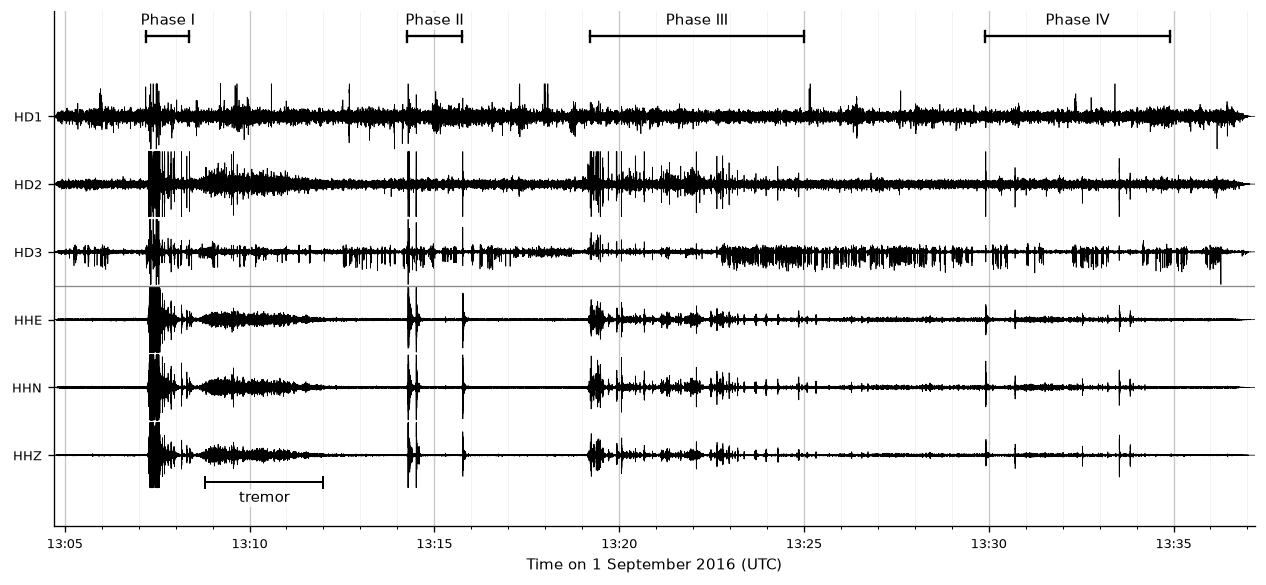

In [8]:
def add_time_bar(ax, t0, t1, y, text, above=True, lw=1.4, fontsize=9):
    """Draw a bracket-style time interval annotation."""
    x0 = mdates.date2num(t0.datetime)
    x1 = mdates.date2num(t1.datetime)

    ax.plot([x0, x1], [y, y], color="black", lw=lw, clip_on=False, zorder=20)
    tick = 0.08
    ax.plot([x0, x0], [y - tick, y + tick], color="black", lw=lw, clip_on=False, zorder=20)
    ax.plot([x1, x1], [y - tick, y + tick], color="black", lw=lw, clip_on=False, zorder=20)

    dy = 0.12 if above else -0.12
    va = "bottom" if above else "top"
    ax.text(
        (x0 + x1) / 2,
        y + dy,
        text,
        ha="center",
        va=va,
        fontsize=fontsize,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.0),
        clip_on=False,
        zorder=25,
    )


def make_overview_figure(
    st: Stream,
    outfile_base: Path,
    plot_start: UTCDateTime,
    plot_end: UTCDateTime,
    phases: list,
    explosion_time: UTCDateTime,
    tremor_start: UTCDateTime | None = None,
    tremor_end: UTCDateTime | None = None,
    normalize_by_group: bool = False,
    clip: float = 3.0,
    trace_gain: float = 0.15,
):
    """Make the 30-minute BCHH overview figure."""
    n = len(st)
    if n == 0:
        raise ValueError("No traces to plot")

    fig, ax = plt.subplots(figsize=(11.0, 5.8))
    offsets = np.arange(n)[::-1].astype(float)
    channel_labels = []

    infra_scales = [robust_scale(tr.data) for tr in st if is_infrasound_channel(tr.stats.channel)]
    seis_scales = [robust_scale(tr.data) for tr in st if is_seismic_channel(tr.stats.channel)]
    group_scale_infra = np.median(infra_scales) if infra_scales else 1.0
    group_scale_seis = np.median(seis_scales) if seis_scales else 1.0

    for i, tr in enumerate(st):
        y0 = offsets[i]
        ch = tr.stats.channel.upper()
        t = trace_time_array_datetime64(tr)
        data = np.nan_to_num(tr.data.astype(float), nan=0.0, posinf=0.0, neginf=0.0)

        if normalize_by_group:
            scale = group_scale_infra if is_infrasound_channel(ch) else group_scale_seis
        else:
            scale = robust_scale(data, percentile=99.3)

        y = y0 + np.clip(data / scale, -clip, clip) * trace_gain
        ax.plot(t, y, '-', color='black', lw=0.45, rasterized=True)
        channel_labels.append(ch)

    ax.set_yticks(offsets)
    ax.set_yticklabels(channel_labels)
    ax.set_ylim(-1.05, n + 0.55)
    ax.set_xlim(mdates.date2num(plot_start.datetime), mdates.date2num(plot_end.datetime))

    ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=range(0, 60, 5)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))
    ax.grid(axis='x', which='major', color='0.78', lw=0.8)
    ax.grid(axis='x', which='minor', color='0.93', lw=0.4)
    ax.set_xlabel('Time on 1 September 2016 (UTC)')

    # Separator between infrasound and seismic channels for default 3+3 order.
    if n >= 6:
        ax.axhline(2.5, color='0.55', lw=0.8)

    phase_y = n + 0.18
    for name, t0, t1 in phases:
        if name.strip().lower() == 'phase i':
            t0 = explosion_time
        if t1 < plot_start or t0 > plot_end:
            continue
        add_time_bar(ax, max(t0, plot_start), min(t1, plot_end), phase_y, name, above=True)

    if tremor_start is not None and tremor_end is not None:
        if tremor_end >= plot_start and tremor_start <= plot_end:
            add_time_bar(
                ax,
                max(tremor_start, plot_start),
                min(tremor_end, plot_end),
                y=-0.4,
                text='tremor',
                above=False,
                lw=1.2,
            )

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.99, top=0.88, bottom=0.14)

    for ext in ['png', 'pdf']:
        fig.savefig(outfile_base.with_suffix(f'.{ext}'), dpi=300, bbox_inches='tight', pad_inches=0.04)

    return fig, ax


fig, ax = make_overview_figure(
    st_overview,
    OUTDIR / 'fig03_bchh_30min_overview',
    PLOT_START,
    PLOT_END,
    phases=PHASES,
    explosion_time=EXPLOSION_TIME,
    tremor_start=TREMOR_START,
    tremor_end=TREMOR_END,
    normalize_by_group=False,
    clip=3.0,
    trace_gain=0.16,
)
plt.show()


## 9. Quick amplitude diagnostic

Use this to sanity-check response-corrected amplitudes before using the figures in the manuscript.


In [9]:
rows = []
for tr in st_ordered:
    x = np.asarray(tr.data, dtype=float)
    rows.append({
        'id': tr.id,
        'channel': tr.stats.channel,
        'units': getattr(tr.stats, 'units', ''),
        'sampling_rate': tr.stats.sampling_rate,
        'min': float(np.nanmin(x)),
        'max': float(np.nanmax(x)),
        'p99_abs': float(np.nanpercentile(np.abs(x), 99)),
        'p99_9_abs': float(np.nanpercentile(np.abs(x), 99.9)),
    })

try:
    import pandas as pd
    display(pd.DataFrame(rows))
except Exception:
    for r in rows:
        print(r)


,id,channel,units,sampling_rate,min,max,p99_abs,p99_9_abs
0,FL.BCHH.00.HD1,HD1,,250.0,-0.145826,0.598798,0.112567,0.184508
1,FL.BCHH.00.HD2,HD2,,250.0,-0.007892,0.059309,0.003544,0.005126
2,FL.BCHH.00.HD3,HD3,,250.0,-0.115557,0.803731,0.028911,0.053913
3,FL.BCHH.00.HHE,HHE,,250.0,-0.001092,0.001003,0.000033,0.000187
4,FL.BCHH.00.HHN,HHN,,250.0,-0.002212,0.001889,0.000043,0.000295
5,FL.BCHH.00.HHZ,HHZ,,250.0,-0.002833,0.002176,0.000057,0.000476


## 10. Optional: load synchronized video/audio track

The audio track is treated as an approximate source-time reference, not an independent calibrated acoustic sensor. If `librosa` or the MP3 file is unavailable, the rest of the notebook still works without audio.


In [10]:
def load_video_audio_as_stream(audio_file: Path, starttime: UTCDateTime, channel='AUD') -> Stream:
    """Load an MP3/WAV file as a single ObsPy trace."""
    try:
        import librosa
    except Exception as e:
        raise ImportError('librosa is required to load MP3 audio') from e

    y, sr = librosa.load(audio_file, sr=None)
    tr = Trace(data=np.asarray(y, dtype=np.float32))
    tr.stats.sampling_rate = sr
    tr.stats.network = 'YT'
    tr.stats.station = 'SYNC'
    tr.stats.location = ''
    tr.stats.channel = channel
    tr.stats.starttime = starttime
    return Stream([tr])


def prepare_audio_for_plot(
    st_audio: Stream,
    zoom_start: UTCDateTime | None = None,
    zoom_end: UTCDateTime | None = None,
    freqmin: float | None = None,
    freqmax: float | None = None,
    audio_time_shift_s: float | None = None,
    demean: bool = True,
    normalize: bool = True,
) -> Stream:
    """Prepare video audio for display using filtering."""
    sta = st_audio.copy()
    for tr in sta:
        if demean:
            tr.detrend('demean')
        if freqmin is not None and freqmax is not None:
            tr.filter('bandpass', freqmin=freqmin, freqmax=freqmax, corners=4, zerophase=ZEROPHASE)
        if audio_time_shift_s is not None:
            tr.stats.starttime += audio_time_shift_s
        if zoom_start is not None and zoom_end is not None:
            tr.trim(zoom_start, zoom_end, pad=False)
        if normalize:
            tr.normalize()
    return sta



st_audio_raw = load_video_audio_as_stream(
    AUDIO_FILE,
    starttime=UTCDateTime('2016-09-01T13:07:10.000'),  # edit if resynchronized
)



## 11. Zoom-figure utilities

The same function can make either:

- **Observed-time plot**: traces remain in UTC; dashed arrival ticks show expected acoustic arrivals.
- **Reduced-time plot**: traces are shifted earlier by travel time; source-time red lines should align with arrivals if the assumed propagation speed and source picks are correct.


In [11]:
'''
def make_zoom_figure(
    st: Stream,
    outfile_base: Path,
    zoom_start: UTCDateTime,
    zoom_end: UTCDateTime,
    source_events: dict,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    direct_seismic_speed_mps: float = DIRECT_SEISMIC_SPEED_MPS,
    hh_use_direct_seismic_speed: bool = HH_USE_DIRECT_SEISMIC_SPEED,
    show_source_times: bool = True,
    show_predicted_arrivals: bool = True,
    show_event_windows: bool = True,
    event_window_s: float = VIDEO_PICK_UNCERTAINTY_S,
    normalize_by_group: bool = False,
    clip: float = 4.0,
    trace_gain: float = 0.18,
):
    """Make the first-sequence zoom figure."""
    n = len(st)
    if n == 0:
        raise ValueError('No traces to plot')

    fig, ax = plt.subplots(figsize=(11.0, 5.2))
    offsets = np.arange(n)[::-1].astype(float)
    channel_labels = []
    channel_y = {}

    infra_scales = [robust_scale(tr.data, percentile=99.5) for tr in st if is_infrasound_channel(tr.stats.channel)]
    seis_scales = [robust_scale(tr.data, percentile=99.5) for tr in st if is_seismic_channel(tr.stats.channel)]
    group_scale_infra = np.median(infra_scales) if infra_scales else 1.0
    group_scale_seis = np.median(seis_scales) if seis_scales else 1.0

    for i, tr in enumerate(st):
        y0 = offsets[i]
        ch = tr.stats.channel.upper()
        channel_y[ch] = y0

        trc = tr.copy().trim(zoom_start, zoom_end, pad=True, fill_value=0)
        t = trace_time_array_datetime64(trc)
        data = np.nan_to_num(trc.data.astype(float), nan=0.0, posinf=0.0, neginf=0.0)

        if normalize_by_group:
            if is_audio_channel(ch):
                scale = robust_scale(data, percentile=99.5)
            elif is_infrasound_channel(ch):
                scale = group_scale_infra
            else:
                scale = group_scale_seis
        else:
            scale = robust_scale(data, percentile=99.5)

        y = y0 + np.clip(data / scale, -clip, clip) * trace_gain
        ax.plot(t, y, '-', color='black', lw=0.55, rasterized=True, zorder=12)

        channel_labels.append('Audio\n1–10 kHz' if is_audio_channel(ch) else ch)

    ax.set_yticks(offsets)
    ax.set_yticklabels(channel_labels)
    ax.set_ylim(-0.7, n - 0.25)
    ax.set_xlim(mdates.date2num(zoom_start.datetime), mdates.date2num(zoom_end.datetime))

    ax.xaxis.set_major_locator(mdates.SecondLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    ax.xaxis.set_minor_locator(mdates.SecondLocator(interval=1))
    ax.grid(axis='x', which='major', color='0.78', lw=0.8, zorder=1)
    ax.grid(axis='x', which='minor', color='0.93', lw=0.4, zorder=1)
    ax.set_xlabel('Time on 1 September 2016 (UTC)')

    if n >= 6:
        ax.axhline(2.5, color='0.55', lw=0.8, zorder=10)

    def draw_channel_vline(x, y0, half_height=0.38, **kwargs):
        ax.vlines(x, y0 - half_height, y0 + half_height, **kwargs)

    ytop = n - 0.15

    for label, source_time in source_events.items():
        if show_source_times and zoom_start <= source_time <= zoom_end:
            x = mdates.date2num(source_time.datetime)
            ax.axvline(x, color='firebrick', lw=1.1, alpha=0.85, zorder=25)
            ax.text(
                x, ytop, label, rotation=90, ha='center', va='top', fontsize=8,
                color='firebrick', alpha=0.90,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=1.0),
                clip_on=False, zorder=30,
            )

        for ch, y0 in channel_y.items():
            if is_audio_channel(ch):
                arrival_time = source_time
            elif ch in sensor_distances_m:
                delay_s = acoustic_or_seismic_delay_s(
                    ch,
                    sensor_distances_m[ch],
                    acoustic_speed_mps,
                    direct_seismic_speed_mps,
                    hh_use_direct_seismic_speed=hh_use_direct_seismic_speed,
                )
                arrival_time = source_time + delay_s
            else:
                continue

            if show_event_windows:
                t_left = arrival_time - event_window_s / 2
                t_right = arrival_time + event_window_s / 2
                if t_right >= zoom_start and t_left <= zoom_end:
                    ax.fill_betweenx(
                        [y0 - 0.42, y0 + 0.42],
                        mdates.date2num(max(t_left, zoom_start).datetime),
                        mdates.date2num(min(t_right, zoom_end).datetime),
                        color='0.75', alpha=0.35, lw=0, zorder=18,
                    )

            if show_predicted_arrivals and zoom_start <= arrival_time <= zoom_end:
                x = mdates.date2num(arrival_time.datetime)
                color = 'firebrick' if is_infrasound_channel(ch) else '0.25'
                draw_channel_vline(x, y0, color=color, lw=0.9, linestyles='--', alpha=0.6, zorder=22)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.99, top=0.96, bottom=0.15)

    for ext in ['png', 'pdf']:
        fig.savefig(outfile_base.with_suffix(f'.{ext}'), dpi=300, bbox_inches='tight', pad_inches=0.04)

    return fig, ax
'''

'\ndef make_zoom_figure(\n    st: Stream,\n    outfile_base: Path,\n    zoom_start: UTCDateTime,\n    zoom_end: UTCDateTime,\n    source_events: dict,\n    sensor_distances_m: dict,\n    acoustic_speed_mps: float,\n    direct_seismic_speed_mps: float = DIRECT_SEISMIC_SPEED_MPS,\n    hh_use_direct_seismic_speed: bool = HH_USE_DIRECT_SEISMIC_SPEED,\n    show_source_times: bool = True,\n    show_predicted_arrivals: bool = True,\n    show_event_windows: bool = True,\n    event_window_s: float = VIDEO_PICK_UNCERTAINTY_S,\n    normalize_by_group: bool = False,\n    clip: float = 4.0,\n    trace_gain: float = 0.18,\n):\n    """Make the first-sequence zoom figure."""\n    n = len(st)\n    if n == 0:\n        raise ValueError(\'No traces to plot\')\n\n    fig, ax = plt.subplots(figsize=(11.0, 5.2))\n    offsets = np.arange(n)[::-1].astype(float)\n    channel_labels = []\n    channel_y = {}\n\n    infra_scales = [robust_scale(tr.data, percentile=99.5) for tr in st if is_infrasound_channel(tr.sta

## 12. Build the zoom stream and figure

Set `REDUCE_TIME=False` to inspect observed UTC arrival times. Set `REDUCE_TIME=True` to shift traces into source time using the effective acoustic speed computed above.


In [15]:

REDUCE_TIME = True

zoom_start = EXPLOSION_TIME - 2
zoom_end = EXPLOSION_TIME + 28

# If the audio trace start time has already been synchronized to source/video time,
# keep this at 0. If the audio is still in observed time, set the needed shift here.
audio_delay_s = 3.9

ZOOM_INFRA_FILTER = {'type': 'bandpass', 'freqmin': 0.05, 'freqmax': 120, 'corners': 4, 'zerophase': ZEROPHASE}
ZOOM_SEIS_FILTER = ZOOM_INFRA_FILTER.copy()
ZOOM_AUDIO_FILTER = {'type': 'bandpass', 'freqmin': 1000, 'freqmax': 2000, 'corners': 4, 'zerophase': ZEROPHASE}

# Rebuild zoom data from response-corrected traces, not from the already filtered overview stream.
st_zoom = select_channels_in_order(st_corr, CHANNEL_ORDER)
st_zoom = preprocess_display_stream(
    st_zoom,
    zoom_start - 10,
    zoom_end + 10,
    infra_filter=ZOOM_INFRA_FILTER,
    seis_filter=ZOOM_SEIS_FILTER,
)

# Add audio. Apply audio filter, but do not shift here;
# time reduction below handles audio_delay_s in one place.
st_audio_zoom = prepare_audio_for_plot(
    st_audio_raw,
    freqmin=ZOOM_AUDIO_FILTER['freqmin'],
    freqmax=ZOOM_AUDIO_FILTER['freqmax'],
    normalize=True,
)
st_zoom = st_audio_zoom + st_zoom
'''

if REDUCE_TIME:
    st_zoom_plot = reduce_stream_to_source_time(
        st_zoom,
        sensor_distances_m=SENSOR_DISTANCES_M,
        acoustic_speed_mps=ACOUSTIC_SPEED_MPS,
        direct_seismic_speed_mps=DIRECT_SEISMIC_SPEED_MPS,
        hh_use_direct_seismic_speed=HH_USE_DIRECT_SEISMIC_SPEED,
        audio_delay_s=audio_delay_s,
    )
    outfile = OUTDIR / 'fig03_bchh_20s_zoom_with_audio_reduced'
    show_predicted_arrivals = False
else:
    st_zoom_plot = st_zoom.copy()
    outfile = OUTDIR / 'fig03_bchh_20s_zoom_with_audio_observed'
    show_predicted_arrivals = True

st_zoom_plot.trim(zoom_start, zoom_end, pad=False)

fig, ax = make_zoom_figure(
    st_zoom_plot,
    outfile,
    zoom_start,
    zoom_end,
    source_events=SOURCE_EVENTS,
    sensor_distances_m=SENSOR_DISTANCES_M,
    acoustic_speed_mps=ACOUSTIC_SPEED_MPS,
    direct_seismic_speed_mps=DIRECT_SEISMIC_SPEED_MPS,
    hh_use_direct_seismic_speed=HH_USE_DIRECT_SEISMIC_SPEED,
    show_source_times=True,
    show_predicted_arrivals=show_predicted_arrivals,
    show_event_windows=False,
    event_window_s=VIDEO_PICK_UNCERTAINTY_S,
    normalize_by_group=False,
    clip=1.2,
    trace_gain=0.4,
)
plt.show()
'''


"\n\nif REDUCE_TIME:\n    st_zoom_plot = reduce_stream_to_source_time(\n        st_zoom,\n        sensor_distances_m=SENSOR_DISTANCES_M,\n        acoustic_speed_mps=ACOUSTIC_SPEED_MPS,\n        direct_seismic_speed_mps=DIRECT_SEISMIC_SPEED_MPS,\n        hh_use_direct_seismic_speed=HH_USE_DIRECT_SEISMIC_SPEED,\n        audio_delay_s=audio_delay_s,\n    )\n    outfile = OUTDIR / 'fig03_bchh_20s_zoom_with_audio_reduced'\n    show_predicted_arrivals = False\nelse:\n    st_zoom_plot = st_zoom.copy()\n    outfile = OUTDIR / 'fig03_bchh_20s_zoom_with_audio_observed'\n    show_predicted_arrivals = True\n\nst_zoom_plot.trim(zoom_start, zoom_end, pad=False)\n\nfig, ax = make_zoom_figure(\n    st_zoom_plot,\n    outfile,\n    zoom_start,\n    zoom_end,\n    source_events=SOURCE_EVENTS,\n    sensor_distances_m=SENSOR_DISTANCES_M,\n    acoustic_speed_mps=ACOUSTIC_SPEED_MPS,\n    direct_seismic_speed_mps=DIRECT_SEISMIC_SPEED_MPS,\n    hh_use_direct_seismic_speed=HH_USE_DIRECT_SEISMIC_SPEED,\n    sho

In [13]:
def channel_delay_s(
    channel: str,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    audio_delay_s: float = 0.0,
) -> float:
    """
    Return propagation delay for one channel.

    For BCHH we assume both infrasound and HH seismic channels record
    the ground-coupled airwave, so all physical BCHH channels use the
    acoustic travel time.

    Audio is treated separately because it may already be synchronized
    to video/source time, or may have a separate manual clock offset.
    """
    ch = channel.upper()

    if is_audio_channel(ch):
        return audio_delay_s

    if ch in sensor_distances_m:
        return sensor_distances_m[ch] / acoustic_speed_mps

    return 0.0

def reduce_stream_to_source_time(
    st: Stream,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    audio_delay_s: float = 0.0,
) -> Stream:
    """
    Shift traces from observed UTC into reduced/source time.

    After this correction, an airwave travelling at acoustic_speed_mps
    should align with the source event time.
    """
    st_red = st.copy()

    for tr in st_red:
        delay = channel_delay_s(
            tr.stats.channel,
            sensor_distances_m=sensor_distances_m,
            acoustic_speed_mps=acoustic_speed_mps,
            audio_delay_s=audio_delay_s,
        )

        print(f"Reducing {tr.id} by {delay:.4f} s")
        tr.stats.starttime -= delay

    return st_red

def make_zoom_figure_simple(
    st: Stream,
    outfile_base: Path,
    zoom_start: UTCDateTime,
    zoom_end: UTCDateTime,
    source_events: dict,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    audio_delay_s: float = 0.0,
    reduced_time: bool = False,
    show_source_times: bool = True,
    show_predicted_arrivals: bool = True,
    show_event_windows: bool = False,
    event_window_s: float = VIDEO_PICK_UNCERTAINTY_S,
    normalize_by_group: bool = False,
    clip: float = 4.0,
    trace_gain: float = 0.18,
):
    """
    Plot BCHH zoom figure.

    Timing convention
    -----------------
    If reduced_time is False:
        traces are shown in observed UTC.
        predicted arrivals are plotted at source_time + travel_time.

    If reduced_time is True:
        traces have already had travel times removed.
        source times are plotted directly.
        predicted arrivals are normally not needed.
    """
    if len(st) == 0:
        raise ValueError("No traces to plot")

    fig, ax = plt.subplots(figsize=(11.0, 5.2))

    offsets = np.arange(len(st))[::-1].astype(float)
    channel_labels = []
    channel_y = {}

    infra_scales = [
        robust_scale(tr.data, percentile=99.5)
        for tr in st
        if is_infrasound_channel(tr.stats.channel)
    ]
    seis_scales = [
        robust_scale(tr.data, percentile=99.5)
        for tr in st
        if is_seismic_channel(tr.stats.channel)
    ]

    group_scale_infra = np.median(infra_scales) if infra_scales else 1.0
    group_scale_seis = np.median(seis_scales) if seis_scales else 1.0

    for i, tr in enumerate(st):
        y0 = offsets[i]
        ch = tr.stats.channel.upper()
        channel_y[ch] = y0

        trc = tr.copy().trim(zoom_start, zoom_end, pad=True, fill_value=0)

        t = trace_time_array_datetime64(trc)
        data = np.nan_to_num(
            trc.data.astype(float),
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        if normalize_by_group:
            if is_audio_channel(ch):
                scale = robust_scale(data, percentile=99.5)
            elif is_infrasound_channel(ch):
                scale = group_scale_infra
            else:
                scale = group_scale_seis
        else:
            scale = robust_scale(data, percentile=99.5)

        if scale <= 0 or not np.isfinite(scale):
            scale = 1.0

        y = y0 + np.clip(data / scale, -clip, clip) * trace_gain
        ax.plot(t, y, "-", color="black", lw=0.55, rasterized=True, zorder=12)

        if is_audio_channel(ch):
            channel_labels.append("Audio\n1–10 kHz")
        else:
            channel_labels.append(ch)

    ax.set_yticks(offsets)
    ax.set_yticklabels(channel_labels)
    ax.set_ylim(-0.7, len(st) - 0.25)
    ax.set_xlim(
        mdates.date2num(zoom_start.datetime),
        mdates.date2num(zoom_end.datetime),
    )

    ax.xaxis.set_major_locator(mdates.SecondLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    ax.xaxis.set_minor_locator(mdates.SecondLocator(interval=1))

    ax.grid(axis="x", which="major", color="0.78", lw=0.8, zorder=1)
    ax.grid(axis="x", which="minor", color="0.93", lw=0.4, zorder=1)
    ax.set_xlabel("Time on 1 September 2016 (UTC)")

    if len(st) >= 6:
        ax.axhline(2.5, color="0.55", lw=0.8, zorder=10)

    def draw_short_vline(x, y0, half_height=0.38, **kwargs):
        ax.vlines(x, y0 - half_height, y0 + half_height, **kwargs)

    ytop = len(st) - 0.15

    for label, source_time in source_events.items():

        if show_source_times and zoom_start <= source_time <= zoom_end:
            x = mdates.date2num(source_time.datetime)

            ax.axvline(
                x,
                color="firebrick",
                lw=1.1,
                alpha=0.85,
                zorder=25,
            )

            ax.text(
                x,
                ytop,
                label,
                rotation=90,
                ha="center",
                va="top",
                fontsize=8,
                color="firebrick",
                alpha=0.90,
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.75,
                    pad=1.0,
                ),
                clip_on=False,
                zorder=30,
            )

        for ch, y0 in channel_y.items():

            if reduced_time:
                arrival_time = source_time
            else:
                delay = channel_delay_s(
                    ch,
                    sensor_distances_m=sensor_distances_m,
                    acoustic_speed_mps=acoustic_speed_mps,
                    audio_delay_s=audio_delay_s,
                )
                arrival_time = source_time + delay

            if show_event_windows:
                t_left = arrival_time - event_window_s / 2
                t_right = arrival_time + event_window_s / 2

                if t_right >= zoom_start and t_left <= zoom_end:
                    ax.fill_betweenx(
                        [y0 - 0.42, y0 + 0.42],
                        mdates.date2num(max(t_left, zoom_start).datetime),
                        mdates.date2num(min(t_right, zoom_end).datetime),
                        color="0.75",
                        alpha=0.35,
                        lw=0,
                        zorder=18,
                    )

            if show_predicted_arrivals and zoom_start <= arrival_time <= zoom_end:
                x = mdates.date2num(arrival_time.datetime)

                color = "firebrick" if is_infrasound_channel(ch) else "0.25"

                draw_short_vline(
                    x,
                    y0,
                    color=color,
                    lw=0.9,
                    linestyles="--",
                    alpha=0.6,
                    zorder=22,
                )

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.99, top=0.96, bottom=0.15)

    for ext in ["png", "pdf"]:
        fig.savefig(
            outfile_base.with_suffix(f".{ext}"),
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.04,
        )

    return fig, ax

Reducing YT.SYNC..AUD by 3.9000 s
Reducing FL.BCHH.00.HD1 by 3.9859 s
Reducing FL.BCHH.00.HD2 by 3.8974 s
Reducing FL.BCHH.00.HD3 by 3.9101 s
Reducing FL.BCHH.00.HHE by 3.9295 s
Reducing FL.BCHH.00.HHN by 3.9295 s
Reducing FL.BCHH.00.HHZ by 3.9295 s
Reducing with acoustic speed = 361.8


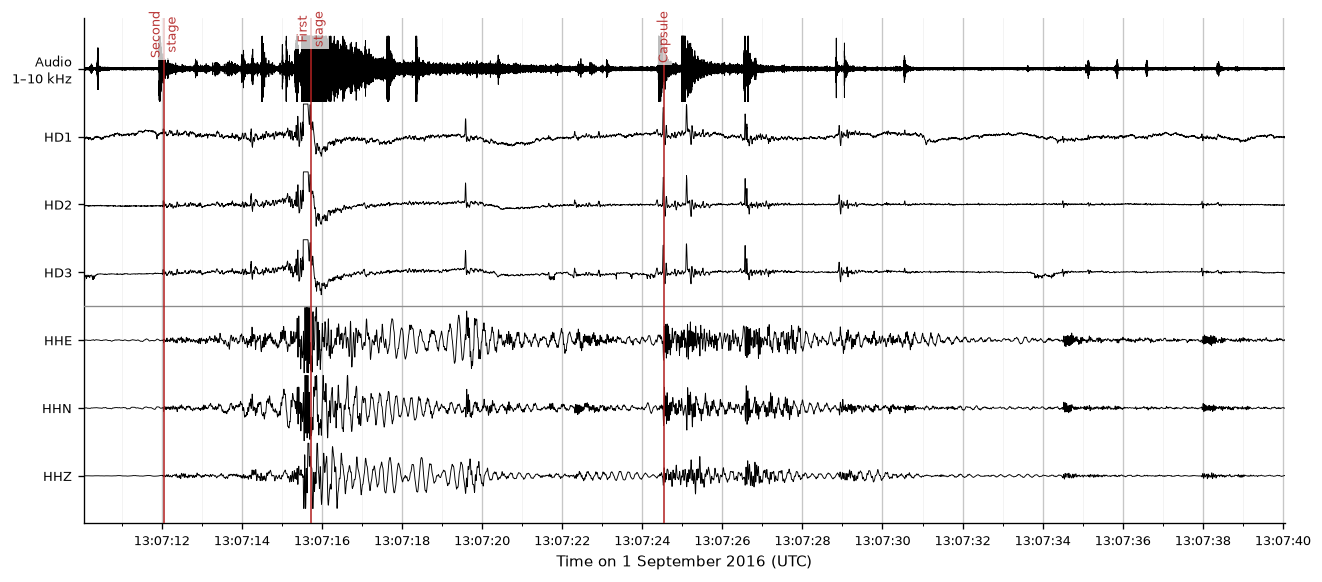

In [16]:
if REDUCE_TIME:
    st_zoom_plot = reduce_stream_to_source_time(
        st_zoom,
        sensor_distances_m=SENSOR_DISTANCES_M,
        acoustic_speed_mps=ACOUSTIC_SPEED_MPS,
        audio_delay_s=audio_delay_s,
    )

    outfile = OUTDIR / "fig03_bchh_20s_zoom_with_audio_reduced"

else:
    st_zoom_plot = st_zoom.copy()
    outfile = OUTDIR / "fig03_bchh_20s_zoom_with_audio_observed"

st_zoom_plot.trim(zoom_start, zoom_end, pad=False)

print(f'Reducing with acoustic speed = {ACOUSTIC_SPEED_MPS:.1f}')

fig, ax = make_zoom_figure_simple(
    st_zoom_plot,
    outfile,
    zoom_start,
    zoom_end,
    source_events=SOURCE_EVENTS,
    sensor_distances_m=SENSOR_DISTANCES_M,
    acoustic_speed_mps=ACOUSTIC_SPEED_MPS,
    audio_delay_s=audio_delay_s,
    reduced_time=REDUCE_TIME,
    show_source_times=True,
    show_predicted_arrivals=not REDUCE_TIME,
    show_event_windows=False,
    event_window_s=VIDEO_PICK_UNCERTAINTY_S,
    normalize_by_group=False,
    clip=1.2,
    trace_gain=0.4,
)

plt.show()

## 13. Timing residual worksheet

Fill in observed pick times for one or more channels/events to see whether the residual is constant, event-dependent, or channel-dependent.


In [ ]:
def required_velocity(distance_m, source_time, observed_arrival_time):
    """Velocity required to connect a source time to an observed arrival time."""
    dt = observed_arrival_time - source_time
    return np.nan if dt <= 0 else distance_m / dt


def predicted_arrival_time(channel, source_time, acoustic_speed_mps=ACOUSTIC_SPEED_MPS):
    """Predicted arrival time for a channel/event under the current timing assumptions."""
    if channel not in SENSOR_DISTANCES_M:
        return source_time
    delay_s = acoustic_or_seismic_delay_s(
        channel,
        SENSOR_DISTANCES_M[channel],
        acoustic_speed_mps,
        DIRECT_SEISMIC_SPEED_MPS,
        hh_use_direct_seismic_speed=HH_USE_DIRECT_SEISMIC_SPEED,
    )
    return source_time + delay_s


# Example structure: replace None with observed UTCDateTime picks from the traces.
pick_rows = []
for event_name, source_time in SOURCE_EVENTS.items():
    for ch in CHANNEL_ORDER:
        predicted = predicted_arrival_time(ch, source_time)
        observed = None  # e.g., UTCDateTime('2016-09-01T13:07:15.950')
        residual_s = None if observed is None else observed - predicted
        v_req = None if observed is None else required_velocity(SENSOR_DISTANCES_M[ch], source_time, observed)
        pick_rows.append({
            'event': event_name.replace('\n', ' '),
            'channel': ch,
            'source_time': source_time.isoformat(),
            'predicted_arrival': predicted.isoformat(),
            'observed_arrival': observed,
            'residual_s': residual_s,
            'required_velocity_mps': v_req,
        })

try:
    import pandas as pd
    display(pd.DataFrame(pick_rows))
except Exception:
    for row in pick_rows:
        print(row)


## 14. PSD

In [ ]:
from scipy.signal import welch
import matplotlib.pyplot as plt
def psd_plot(st, xlims=None, ylims=None, nyquist_percentage=0.95, plot_trace=False):
    for tr in st:
        tr = tr.copy()
        tr.detrend("demean")
        tr.taper(max_percentage=0.05)
        if plot_trace:
            tr.plot()

        fs = tr.stats.sampling_rate
        highest_freq_to_plot = 0.5 * fs * nyquist_percentage
        x = tr.data.astype(float)

        f, Pxx = welch(
            x,
            fs=fs,
            nperseg=min(4096, len(x)),
            noverlap=None,
            scaling="density"
        )

        plt.figure(figsize=(8, 4))
        plt.loglog(f, Pxx)
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Power spectral density")
        plt.title(f"PSD for {tr.id}")
        if xlims is None:
            xlims = (f[1], highest_freq_to_plot)
        xlims = (max(xlims[0], f[1]), min(xlims[1], highest_freq_to_plot))
        plt.xlim(xlims)
        if ylims is not None:
            plt.ylim(ylims)
        plt.grid(True, alpha=0.3)
        plt.show()

st_spec = st_audio_raw.copy().trim(starttime=EXPLOSION_TIME+3, endtime=EXPLOSION_TIME+10)
psd_plot(st_spec, ylims=(1e-10, 1e-3), plot_trace=True)#, xlims=(1, 10000))